In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("novagen_dataset.csv")

In [3]:
df

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9544,5.0,22.0,109.0,203.0,98.0,75.0,8.0,1.0,6.0,0.0,...,0,2,2,1,0,True,False,True,False,False
9545,94.0,26.0,144.0,203.0,96.0,72.0,8.0,4.0,2.0,1.0,...,1,0,1,0,2,False,True,False,True,False
9546,10.0,23.0,185.0,198.0,103.0,72.0,4.0,5.0,5.0,6.0,...,1,0,2,0,1,True,False,True,False,False
9547,50.0,29.0,166.0,200.0,100.0,74.0,8.0,2.0,3.0,4.0,...,2,0,0,1,1,True,False,True,False,False


In [4]:
df.head()
df.info()
df.isnull().sum()
df.describe()
df['Target'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

Target
1    4979
0    4570
Name: count, dtype: int64

In [26]:
df["Target"].unique()

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [24]:
df['Exercise_Hours'] = df['Exercise_Hours'].abs()

Text(0.5, 1.0, 'Is person healthy or Unhealthy?')

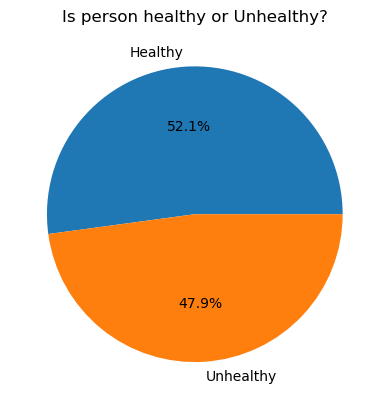

In [7]:
# how balanced our classes are?

classes_count = df["Target"].value_counts()

plt.pie(classes_count, labels=["Healthy","Unhealthy"], autopct="%1.1f%%")
plt.title("Is person healthy or Unhealthy?")

In [ ]:
X = df.drop(columns=["Target"])
y = df["Target"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Since the objective is to identify individuals at health risk, Recall is prioritized to minimize false negatives. Missing an unhealthy individual could lead to serious consequences, therefore models are primarily evaluated using Recall along with F1-score for balanced performance.

In [10]:
# Logistic Regression Model
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.8376237623762376
precision_score : 0.8285994123408423
accuracy_score : 0.8225130890052356
f1_score : 0.8330871491875923
cm: [[725 175]
 [164 846]]


In [21]:
# KNN Model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.8831683168316832
precision_score : 0.8902195608782435
accuracy_score : 0.8806282722513089
f1_score : 0.8866799204771372
cm: [[790 110]
 [118 892]]


In [12]:
# Support Vector Machine Model
svc = SVC()
svc.fit(X_train_scaled, y_train)

y_pred = svc.predict(X_test_scaled)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.9425742574257425
precision_score : 0.9324191968658179
accuracy_score : 0.9335078534031414
f1_score : 0.9374692269817824
cm: [[831  69]
 [ 58 952]]


Feature scaling is not applied to the following models (GaussianNB, DecisionTree, RandomForest, GradientBoosting, and XGBoost) because these algorithms are generally not sensitive to feature scaling.

In [13]:
# DicisionTreeClassifier Model

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.8891089108910891
precision_score : 0.9061553985872856
accuracy_score : 0.8926701570680629
f1_score : 0.8975512243878061
cm: [[807  93]
 [112 898]]


In [14]:
# RandomForestClassifier Model

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.9396039603960396
precision_score : 0.9471057884231537
accuracy_score : 0.9403141361256544
f1_score : 0.9433399602385686
cm: [[847  53]
 [ 61 949]]


In [15]:
# GaussianNB Model

gnb= GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.80990099009901
precision_score : 0.8450413223140496
accuracy_score : 0.8209424083769633
f1_score : 0.8270980788675429
cm: [[750 150]
 [192 818]]


In [16]:
# GradientBoostingClassifier Model

gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)

y_pred = gb_clf.predict(X_test)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.9247524752475248
precision_score : 0.9211045364891519
accuracy_score : 0.9183246073298429
f1_score : 0.9229249011857708
cm: [[820  80]
 [ 76 934]]


In [17]:
# XGBClassifier Model

xgb_clf = XGBClassifier()
xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)

print("Recall :", recall_score(y_test, y_pred))
print("precision_score :", precision_score(y_test, y_pred))
print("accuracy_score :", accuracy_score(y_test, y_pred))
print("f1_score :", f1_score(y_test, y_pred))
print("cm:", confusion_matrix(y_test, y_pred))

Recall : 0.9415841584158415
precision_score : 0.9548192771084337
accuracy_score : 0.9455497382198953
f1_score : 0.9481555333998006
cm: [[855  45]
 [ 59 951]]


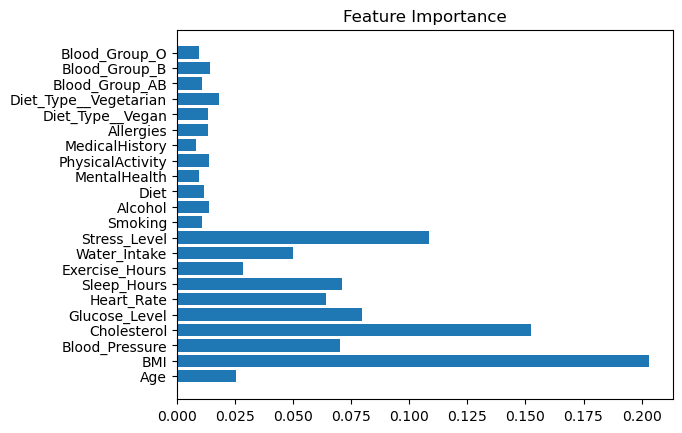

In [18]:
importance = xgb_clf.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_clf, X, y, cv=5)
print(scores.mean())

0.9442871600218311


In [25]:
models = {
    "Logistic Regression": (lr, X_test_scaled, y_test),
    "KNN":                 (knn, X_test_scaled, y_test),
    "SVM":                 (svc, X_test_scaled, y_test),
    "Decision Tree":       (dtc, X_test, y_test),
    "Random Forest":       (rfc, X_test, y_test),
    "Naive Bayes":         (gnb, X_test, y_test),
    "Gradient Boosting":   (gb_clf, X_test, y_test),
    "XGBoost":             (xgb_clf, X_test, y_test),
}

rows = []
for name, (model, X_t, y_t) in models.items():
    yp = model.predict(X_t)
    rows.append({"Model": name,
                 "Recall":    round(recall_score(y_t, yp), 4),
                 "Precision": round(precision_score(y_t, yp), 4),
                 "F1 Score":  round(f1_score(y_t, yp), 4),
                 "Accuracy":  round(accuracy_score(y_t, yp), 4)})

pd.DataFrame(rows)

,Model,Recall,Precision,F1 Score,Accuracy
0,Logistic Regression,0.8376,0.8286,0.8331,0.8225
1,KNN,0.8832,0.8902,0.8867,0.8806
2,SVM,0.9426,0.9324,0.9375,0.9335
3,Decision Tree,0.8891,0.9062,0.8976,0.8927
4,Random Forest,0.9396,0.9471,0.9433,0.9403
5,Naive Bayes,0.8099,0.8450,0.8271,0.8209
6,Gradient Boosting,0.9248,0.9211,0.9229,0.9183
7,XGBoost,0.9416,0.9548,0.9482,0.9455


Among all models, XGBoost achieved the best overall performance with an accuracy of 94.5% and F1-score of 94.8%. It also maintained a high recall (94.1%), making it effective at identifying individuals at health risk while minimizing false negatives.